# EXAMEN · Parcial 1 · Resolver el caso de un cliente
**Programación Aplicada a la Inteligencia de Mercados · UIDE · Juan Carlos Correa / Docente**

**Examen individual · 60 minutos.** Es el mismo cuaderno del Taller de práctica: los mismos 7 pasos, con tu propio cliente.

### El botón que vas a usar

Cada paso tiene **una celda gris con un título**. A la izquierda del título está el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> (un círculo con un triángulo que apunta a la derecha; al pasar el mouse se pone oscuro). **Pulsar ese botón hace el paso.**

![Así se ve la celda de un paso: a la izquierda el botón, a la derecha los recuadros para escribir](https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/celda_paso.png)

- En este cuaderno, el símbolo <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> significa siempre y solamente **ese botón**.
- Si la celda tiene **recuadros para escribir** (a la derecha del título), primero escribes en ellos y después pulsas <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.
- Cuando el paso termina, aparece debajo lo que salió y una línea que empieza con **✅**.
- La primera vez que pulses <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">, Colab muestra un aviso: *«Advertencia: Este notebook no fue creado por Google»*. Pulsa **Ejecutar de todos modos**. Es normal.

### El camino, de un vistazo
| Paso | Qué haces |
|:---:|---|
| **0** | Ponerle tu nombre al cuaderno |
| **1** | Conocer a tu cliente |
| **2** | Traer sus datos |
| **3** | Comprobar un dato con tus propios ojos |
| **4** | Medir cuánto cambió |
| **5** | Encontrar lo más importante |
| **6** | Responderle al cliente |
| **7** | Guardar y entregar |

Cada paso usa lo que salió del paso anterior: **hazlos en orden y sin saltarte ninguno.**

### Reglas del examen
- **Individual.** Trabajas solo con este cuaderno y el manual del examen (PDF).
- **El profesor que está en el aula solo acompaña: no revisa, no califica y no puede ayudarte.** Todo lo que necesitas está en el manual y en este cuaderno.
- La IA se permite **solo para entender un mensaje**, y se declara en el Paso 6.

## PASO 0 · Ponerle tu nombre a tu cuaderno

**🔗 Lo que ya tienes:** este cuaderno abierto en Colab. Lo bajaste de Canvas y lo subiste a Colab, como dice la guía. Colab ya lo guardó en tu Google Drive.

**🎯 En este paso:** le pones tu nombre, para encontrarlo y entregarlo sin confusiones.

**👆 Qué haces:** haz clic en el nombre del cuaderno (arriba a la izquierda), bórralo, escribe **`EXAMEN_P1_TuApellido`** (con tu apellido) y pulsa **Enter**.

**👀 Qué debes ver:** arriba a la izquierda, el nombre `EXAMEN_P1_TuApellido.ipynb`.

**🧩 Lo que te llevas al Paso 1:** tu cuaderno, listo para trabajar.

## PASO 1 · Conocer a tu cliente

**🔗 Lo que ya tienes:** tu copia del cuaderno (Paso 0).

**🎯 En este paso:** descubres quién es tu cliente, qué problema tiene, qué te pregunta y cuál es su regla (su **umbral**: el porcentaje de cambio que le importa).

**👆 Qué haces:** 1. En la celda gris de abajo, abre la lista **CASO** y elige **tu nombre** (la lista está ordenada por apellido). Cada estudiante tiene un cliente distinto.
2. Pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda.

**👀 Qué debes ver:** la ficha de tu cliente: su problema, su pregunta, su regla, de dónde salen los datos, **qué miden** y **cómo leer los números**. Al final: `✅ Paso 1 listo`.

**🧩 Lo que te llevas al paso siguiente:** tu cliente y su pregunta. **Léela con calma: todo lo que sigue sirve para responderla.**

In [5]:
#@title PASO 1 · Conocer a tu cliente { display-mode: "form" }
#@markdown Elige tu caso en la lista y pulsa el botón redondo
CASO = "Examen · David Ibarra" #@param ["— Elige tu nombre —", "Examen · Diana Andrade", "Examen · Henry Cupacán", "Examen · David Ibarra", "Examen · Anthony Landeta", "Examen · Nayeli Lima", "Examen · Mateo Murgueitio", "Examen · Paula Paredes", "Examen · Adrián Punina", "Examen · Saúl Robalino", "Examen · Emily Ruiz", "Examen · Micaela Samaniego", "Examen · Sara Sánchez", "Examen · Jaime Tapia", "Examen · Zara Tigua", "Examen · David Uriguen"]
# ═══════════════════════════════════════════════════════════════════════
#  EL MOTOR DEL CUADERNO · Parcial 1 · UIDE · Juan Carlos Correa
#  No hace falta leer ni cambiar nada de esto: cada paso lo usa solo.
# ═══════════════════════════════════════════════════════════════════════
import re, io, json, time, requests, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 200)
RECURSOS = "https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/"
AGENTE = {"User-Agent": "Mozilla/5.0 (ObservatorioUIDE; proyecto academico)"}
PAISES = {"ECU": ("Ecuador", "EC"), "COL": ("Colombia", "CO"), "PER": ("Perú", "PE"), "GTM": ("Guatemala", "GT"),
          "DOM": ("República Dominicana", "DO")}
NOMBRE_IND = {"FP.CPI.TOTL": "Índice de precios al consumidor (2010 = 100)", "IT.NET.USER.ZS": "Personas que usan internet (% de la población)", "NE.CON.PRVT.PC.KD": "Consumo de los hogares por persona (USD constantes de 2015)", "BX.TRF.PWKR.CD.DT": "Remesas personales recibidas (USD corrientes)", "NY.GDP.PCAP.KD": "PIB por persona (USD constantes de 2015)"}
PRACTICA = {}
EXAMEN = {"Examen · Henry Cupacán": {"titulo": "Examen · Caso 01", "fuente": "bm", "valores": {"PAIS_2": "PER", "INDICADOR": "FP.CPI.TOTL", "DESDE": 2019}, "umbral": 10, "cliente": "Supermercados Ahorro Andino, cadena ecuatoriana que evalúa abrir tres locales en Lima", "problema": "Va a abrir tres locales en Lima y quiere saber cada cuánto revisar su lista de precios. No mira producto por producto: mira cuánto subieron los precios en general en cada país (el índice de precios al consumidor). Su regla: si en un país los precios de la economía subieron 10 % o más desde 2019, allí hay que revisar la lista de precios más seguido que una vez al año.", "pregunta": "¿En qué país subieron más los precios desde 2019 y con qué frecuencia recomendarías revisar la lista de precios en Lima?", "de_donde": "Banco Mundial · Índice de precios al consumidor (2010 = 100) · Ecuador y Perú, cada año desde 2019.", "que_miden": "El índice de precios al consumidor (IPC) de cada país: cuánto cuesta, en promedio, lo que compran las familias (comida, arriendo, transporte, servicios). No son los precios de los productos del cliente: es el nivel general de precios de la economía.", "como_leer": "Es un índice, no dólares ni pesos: 100 = los precios del año 2010. Si marca 134, las cosas cuestan 34 % más que en 2010. Por eso se puede comparar Ecuador (que usa dólares) con un país que usa otra moneda: lo que importa es cuánto subió, en %.", "titulo_grafico": "Índice de precios al consumidor: Ecuador y Perú", "estudiante": "Henry Cupacán", "equipo": "G01"}, "Examen · Nayeli Lima": {"titulo": "Examen · Caso 02", "fuente": "tia", "valores": {"productos": [["Azúcar San Carlos 2 kg", "https://www.tia.com.ec/supermercado/comestibles/azucar-endulzantes-y-panela/azucar-san-carlos-2-kg-251221000.html", 2.3], ["Aceite Palma de Oro 900 cc", "https://www.tia.com.ec/supermercado/comestibles/aceites-y-vinagres/aceite-palma-de-oro-900-cc-257407000.html", 2.25], ["Huevos Indaves x12", "https://www.tia.com.ec/supermercado/lacteos/huevos/huevos-grandes-indaves-12-uni-251702000.html", 2.7]]}, "umbral": 5, "cliente": "Doña Rosa, dueña de una tienda de barrio en Chillogallo (sur de Quito)", "problema": "Sus vecinos le dicen que en Tía todo está más barato. Ella vende azúcar, aceite y huevos a los precios de la tabla del Paso 2. Si Tía es 5 % o más barata en un producto, teme perder a esos clientes.", "pregunta": "¿En qué productos Tía le gana a Doña Rosa por más de 5 % y qué le recomendarías hacer con esos precios?", "de_donde": "La página de Tía (tia.com.ec): el precio de hoy de cada producto, frente al precio de tu cliente.", "que_miden": "El precio de cada producto hoy en Tía, frente al precio que tiene tu cliente.", "como_leer": "Los precios están en dólares por unidad. El cuaderno calcula la diferencia en %: negativo = Tía más barata que el cliente; positivo = Tía más cara.", "titulo_grafico": "Doña Rosa: sus precios frente a Tía hoy", "estudiante": "Nayeli Lima", "equipo": "G01"}, "Examen · Mateo Murgueitio": {"titulo": "Examen · Caso 03", "fuente": "curso", "valores": {"ARCHIVO": "curso_cafeteria.csv"}, "umbral": 10, "cliente": "Café Rumiñahui, cafetería de Sangolquí con tres líneas de venta", "problema": "El dueño quiere saber qué línea de su negocio (café, sánduches o postres) creció y cuál cayó entre enero y agosto de 2026. Le importa todo cambio de 10 % o más.", "pregunta": "¿Qué línea debería potenciar y cuál debería revisar? Justifica con las cifras.", "de_donde": "Los datos de tu cliente, guardados por el profesor: USD vendidos al mes, mes a mes, de enero a agosto de 2026.", "que_miden": "Los USD vendidos al mes de cada línea del negocio (Café, Sánduches, Postres), mes a mes.", "como_leer": "El cuaderno compara enero con agosto, en %: positivo = creció; negativo = cayó.", "titulo_grafico": "Café Rumiñahui: USD vendidos al mes, enero a agosto de 2026", "estudiante": "Mateo Murgueitio", "equipo": "G01"}, "Examen · Sara Sánchez": {"titulo": "Examen · Caso 04", "fuente": "bm", "valores": {"PAIS_2": "COL", "INDICADOR": "IT.NET.USER.ZS", "DESDE": 2018}, "umbral": 25, "cliente": "Clic Andino, agencia quiteña de marketing digital que quiere vender tiendas en línea en Colombia", "problema": "La agencia empezará por el país donde el uso de internet crece más rápido. Mira el porcentaje de personas que usan internet en cada país y considera «crecimiento fuerte» que ese porcentaje haya crecido 25 % o más desde 2018.", "pregunta": "¿En qué país creció más rápido el uso de internet y por cuál mercado le conviene empezar a la agencia?", "de_donde": "Banco Mundial · Personas que usan internet (% de la población) · Ecuador y Colombia, cada año desde 2018.", "que_miden": "El porcentaje de la población de cada país que usa internet.", "como_leer": "Es un porcentaje: 77 quiere decir que 77 de cada 100 personas usan internet. El cuaderno calcula cuánto creció ese porcentaje, en %.", "titulo_grafico": "Personas que usan internet: Ecuador y Colombia", "estudiante": "Sara Sánchez", "equipo": "G01"}, "Examen · Zara Tigua": {"titulo": "Examen · Caso 05", "fuente": "tia", "valores": {"productos": [["Yogur Alpina 900 g guanábana", "https://www.tia.com.ec/bebida-de-yogurt-alpina-funda-900-g-guanabana-cremoso-271246000.html", 1.42], ["Yogur Frush 900 g mora", "https://www.tia.com.ec/bebida-de-yogurt-frush-900-g-mora-271176000.html", 1.25], ["Avena Toni 1 l naranjilla", "https://www.tia.com.ec/bebida-avena-casera-toni-tetrabrik-1-l-naranjilla-330507000.html", 2.4]]}, "umbral": 5, "cliente": "Minimarket El Vecino, en Carcelén (norte de Quito)", "problema": "El dueño vende yogures y avena a los precios de la tabla del Paso 2. Tía abrió un local a tres cuadras y quiere saber si él está caro o barato frente a Tía. Su regla: una diferencia de 5 % o más, a favor o en contra, merece una decisión.", "pregunta": "¿En qué producto la diferencia con Tía supera el 5 % y qué harías con su precio?", "de_donde": "La página de Tía (tia.com.ec): el precio de hoy de cada producto, frente al precio de tu cliente.", "que_miden": "El precio de cada producto hoy en Tía, frente al precio que tiene tu cliente.", "como_leer": "Los precios están en dólares por unidad. El cuaderno calcula la diferencia en %: negativo = Tía más barata que el cliente; positivo = Tía más cara.", "titulo_grafico": "Minimarket El Vecino: sus precios frente a Tía hoy", "estudiante": "Zara Tigua", "equipo": "G01"}, "Examen · Diana Andrade": {"titulo": "Examen · Caso 06", "fuente": "curso", "valores": {"ARCHIVO": "curso_tienda_online.csv"}, "umbral": 20, "cliente": "Moda Andina, tienda de ropa en línea que vende por Instagram, TikTok y Google", "problema": "La gerente reparte cada mes su presupuesto de publicidad entre Instagram, TikTok y Google. Solo mueve dinero si los pedidos de un canal cambiaron 20 % o más entre enero y agosto de 2026.", "pregunta": "¿A qué canal le moverías presupuesto, desde cuál, y por qué?", "de_donde": "Los datos de tu cliente, guardados por el profesor: pedidos al mes, mes a mes, de enero a agosto de 2026.", "que_miden": "Los pedidos al mes de cada línea del negocio (Instagram, TikTok, Google), mes a mes.", "como_leer": "El cuaderno compara enero con agosto, en %: positivo = creció; negativo = cayó.", "titulo_grafico": "Moda Andina: pedidos al mes, enero a agosto de 2026", "estudiante": "Diana Andrade", "equipo": "G02"}, "Examen · Anthony Landeta": {"titulo": "Examen · Caso 07", "fuente": "bm", "valores": {"PAIS_2": "COL", "INDICADOR": "NE.CON.PRVT.PC.KD", "DESDE": 2019}, "umbral": 5, "cliente": "Casa Plena, cadena ecuatoriana de electrodomésticos que decide dónde invertir su publicidad de 2027", "problema": "La cadena mira cuánto gastan los hogares por persona en cada país (el consumo, sin inflación). Si creció 5 % o más desde 2019, las familias están comprando más y conviene una campaña de imagen; si no, conviene una campaña de promociones y crédito.", "pregunta": "¿Dónde harías campaña de imagen y dónde campaña de promociones?", "de_donde": "Banco Mundial · Consumo de los hogares por persona (USD constantes de 2015) · Ecuador y Colombia, cada año desde 2019.", "que_miden": "Cuánto gastan en consumo los hogares de cada país, en promedio por persona, en un año.", "como_leer": "Está en dólares «constantes de 2015»: dólares a los que ya se les quitó la inflación, para comparar años sin que la subida de precios engañe. Los dos países están en dólares.", "titulo_grafico": "Consumo de los hogares por persona: Ecuador y Colombia", "estudiante": "Anthony Landeta", "equipo": "G02"}, "Examen · Paula Paredes": {"titulo": "Examen · Caso 08", "fuente": "tia", "valores": {"productos": [["Avena Toni 250 ml naranjilla", "https://www.tia.com.ec/bebida-avena-casera-toni-tetrabrik-250-ml-naranjilla-330503002.html", 0.8], ["Avena con leche Toni 250 ml", "https://www.tia.com.ec/bebida-avena-con-leche-toni-tetrabrik-250-ml-canela-330509000.html", 1.05], ["Avena Vita 900 ml", "https://www.tia.com.ec/bebida-avena-vita-900-ml-maracuya-y-naranjilla-331002000.html", 0.95]]}, "umbral": 8, "cliente": "El bar de un colegio de Conocoto, que hoy compra sus bebidas a un distribuidor", "problema": "La administradora paga al distribuidor los precios de la tabla del Paso 2. Se pregunta si le convendría comprar esas bebidas en Tía. Solo cambia de proveedor si Tía es 8 % o más barata.", "pregunta": "¿Qué bebidas le conviene comprar en Tía y cuáles seguir comprando al distribuidor?", "de_donde": "La página de Tía (tia.com.ec): el precio de hoy de cada producto, frente al precio de tu cliente.", "que_miden": "El precio de cada producto hoy en Tía, frente al precio que tiene tu cliente.", "como_leer": "Los precios están en dólares por unidad. El cuaderno calcula la diferencia en %: negativo = Tía más barata que el cliente; positivo = Tía más cara.", "titulo_grafico": "El bar de un colegio de Conocoto: sus precios frente a Tía hoy", "estudiante": "Paula Paredes", "equipo": "G02"}, "Examen · Saúl Robalino": {"titulo": "Examen · Caso 09", "fuente": "curso", "valores": {"ARCHIVO": "curso_gimnasio.csv"}, "umbral": 8, "cliente": "Gimnasio Cumbre Activa, en Cumbayá, con planes mensual, trimestral y anual", "problema": "El administrador quiere saber qué plan (mensual, trimestral o anual) gana o pierde socios entre enero y agosto de 2026. Un cambio de 8 % o más le obliga a actuar.", "pregunta": "¿Qué plan está en problemas, cuál va bien y qué harías con cada uno?", "de_donde": "Los datos de tu cliente, guardados por el profesor: socios activos, mes a mes, de enero a agosto de 2026.", "que_miden": "Los socios activos de cada línea del negocio (Plan mensual, Plan trimestral, Plan anual), mes a mes.", "como_leer": "El cuaderno compara enero con agosto, en %: positivo = creció; negativo = cayó.", "titulo_grafico": "Gimnasio Cumbre Activa: socios activos, enero a agosto de 2026", "estudiante": "Saúl Robalino", "equipo": "G02"}, "Examen · David Uriguen": {"titulo": "Examen · Caso 10", "fuente": "bm", "valores": {"PAIS_2": "GTM", "INDICADOR": "BX.TRF.PWKR.CD.DT", "DESDE": 2019}, "umbral": 50, "cliente": "Giro Familiar, fintech ecuatoriana que diseña una app para recibir remesas del exterior", "problema": "La fintech lanzará primero su app en el país donde las remesas (el dinero que envían los migrantes a sus familias) crecen más rápido. Considera «crecimiento atractivo» un aumento de 50 % o más desde 2019.", "pregunta": "¿En qué país crecieron más rápido las remesas y dónde lanzarías primero la app?", "de_donde": "Banco Mundial · Remesas personales recibidas (USD corrientes) · Ecuador y Guatemala, cada año desde 2019.", "que_miden": "El dinero que los migrantes envían a su país (remesas), en total, en un año.", "como_leer": "Está en dólares de cada año. 7.73B quiere decir 7 730 millones de dólares.", "titulo_grafico": "Remesas personales recibidas: Ecuador y Guatemala", "estudiante": "David Uriguen", "equipo": "G02"}, "Examen · David Ibarra": {"titulo": "Examen · Caso 11", "fuente": "tia", "valores": {"productos": [["Aceite Criollo 900 ml", "https://www.tia.com.ec/aceite-criollo-900-ml-257468000.html", 2.2], ["Aceite achiote La Favorita 500 cc", "https://www.tia.com.ec/aceite-con-achiote-la-favorita-500-cc-257464000.html", 1.9], ["Aceite canola Vivi 1 l", "https://www.tia.com.ec/aceite-de-canola-vivi-1-l-258345000.html", 3.6]]}, "umbral": 5, "cliente": "Sazón Quiteña, restaurante de almuerzos del centro de Quito", "problema": "El restaurante compra aceite a un proveedor a los precios de la tabla del Paso 2 y usa mucho cada semana. Si Tía es 5 % o más barata, conviene cambiar la compra.", "pregunta": "¿Qué aceites le conviene comprar en Tía y cuánto ahorraría por unidad?", "de_donde": "La página de Tía (tia.com.ec): el precio de hoy de cada producto, frente al precio de tu cliente.", "que_miden": "El precio de cada producto hoy en Tía, frente al precio que tiene tu cliente.", "como_leer": "Los precios están en dólares por unidad. El cuaderno calcula la diferencia en %: negativo = Tía más barata que el cliente; positivo = Tía más cara.", "titulo_grafico": "Sazón Quiteña: sus precios frente a Tía hoy", "estudiante": "David Ibarra", "equipo": "G03"}, "Examen · Adrián Punina": {"titulo": "Examen · Caso 12", "fuente": "curso", "valores": {"ARCHIVO": "curso_floreria.csv"}, "umbral": 15, "cliente": "Flores del Valle, florería de Tumbaco que vende en mostrador, por WhatsApp y por su página web", "problema": "La dueña quiere saber por dónde le llegan cada vez más pedidos: mostrador, WhatsApp o página web. Solo le preocupa un cambio de 15 % o más entre enero y agosto de 2026.", "pregunta": "¿Qué canal crece más, cuál cae, y dónde pondría una persona más para atender?", "de_donde": "Los datos de tu cliente, guardados por el profesor: pedidos al mes, mes a mes, de enero a agosto de 2026.", "que_miden": "Los pedidos al mes de cada línea del negocio (Mostrador, WhatsApp, Página web), mes a mes.", "como_leer": "El cuaderno compara enero con agosto, en %: positivo = creció; negativo = cayó.", "titulo_grafico": "Flores del Valle: pedidos al mes, enero a agosto de 2026", "estudiante": "Adrián Punina", "equipo": "G03"}, "Examen · Emily Ruiz": {"titulo": "Examen · Caso 13", "fuente": "bm", "valores": {"PAIS_2": "DOM", "INDICADOR": "NY.GDP.PCAP.KD", "DESDE": 2019}, "umbral": 10, "cliente": "Hoteles Equinoccio, cadena hotelera ecuatoriana que evalúa construir en Punta Cana", "problema": "Un hotel se construye pensando en diez años. Los inversionistas quieren un país donde el PIB por persona (el ingreso promedio de la gente, sin inflación) haya crecido 10 % o más desde 2019.", "pregunta": "¿Qué economía cumple la condición y qué le dirías a los inversionistas?", "de_donde": "Banco Mundial · PIB por persona (USD constantes de 2015) · Ecuador y República Dominicana, cada año desde 2019.", "que_miden": "El PIB por persona: lo que produce la economía en un año, dividido para cada habitante. Mide si la gente, en promedio, tiene más o menos ingresos.", "como_leer": "Está en dólares «constantes de 2015» (sin inflación), para los dos países.", "titulo_grafico": "PIB por persona: Ecuador y República Dominicana", "estudiante": "Emily Ruiz", "equipo": "G03"}, "Examen · Micaela Samaniego": {"titulo": "Examen · Caso 14", "fuente": "tia", "valores": {"productos": [["Bebida de soya Oriental 1 l", "https://www.tia.com.ec/bebida-de-soya-oriental-tetrabrik-1000-ml-330552000.html", 2.75], ["Aceite de aguacate Zico 155 ml", "https://www.tia.com.ec/aceite-de-aguacate-zico-155-ml-253190000.html", 5.1], ["Aceite La Favorita light 900 ml", "https://www.tia.com.ec/aceite-50-por-ciento-menos-grasa-la-favorita-900-ml-258363000.html", 3.1]]}, "umbral": 5, "cliente": "Vida Verde, tienda de productos saludables en La Carolina", "problema": "La tienda vende estos productos a los precios de la tabla del Paso 2. Sus clientas comparan con Tía desde el celular. Si Tía es 5 % o más barata, la tienda pierde la venta.", "pregunta": "¿En qué productos Vida Verde está cara frente a Tía y qué le recomendarías?", "de_donde": "La página de Tía (tia.com.ec): el precio de hoy de cada producto, frente al precio de tu cliente.", "que_miden": "El precio de cada producto hoy en Tía, frente al precio que tiene tu cliente.", "como_leer": "Los precios están en dólares por unidad. El cuaderno calcula la diferencia en %: negativo = Tía más barata que el cliente; positivo = Tía más cara.", "titulo_grafico": "Vida Verde: sus precios frente a Tía hoy", "estudiante": "Micaela Samaniego", "equipo": "G03"}, "Examen · Jaime Tapia": {"titulo": "Examen · Caso 15", "fuente": "curso", "valores": {"ARCHIVO": "curso_heladeria.csv"}, "umbral": 8, "cliente": "Helados La Cima, heladería con tres locales en Quito", "problema": "El dueño quiere renovar el local que peor va y vigilar los demás. Le importa un cambio de 8 % o más en ventas entre enero y agosto de 2026.", "pregunta": "¿Qué local renovarías, cuál vigilarías y por qué?", "de_donde": "Los datos de tu cliente, guardados por el profesor: USD vendidos al mes, mes a mes, de enero a agosto de 2026.", "que_miden": "Los USD vendidos al mes de cada línea del negocio (Local Norte, Local Centro, Local Valle), mes a mes.", "como_leer": "El cuaderno compara enero con agosto, en %: positivo = creció; negativo = cayó.", "titulo_grafico": "Helados La Cima: USD vendidos al mes, enero a agosto de 2026", "estudiante": "Jaime Tapia", "equipo": "G03"}}
OBS = globals().setdefault("OBS", {})

def _linea():
    print("─" * 70)

def _falta(paso):
    print(f"✋ Todavía no puedes hacer este paso: primero pulsa el botón redondo del {paso}.")

def _pedir(url, veces=2, espera=20):
    for intento in range(1, veces + 1):
        try:
            r = requests.get(url, headers=AGENTE, timeout=espera)
            if r.status_code == 200:
                return r
            print(f"   (intento {intento}: la fuente respondió {r.status_code})")
        except Exception:
            print(f"   (intento {intento}: la fuente está tardando, el cuaderno sigue intentando…)")
        time.sleep(2 * intento)
    return None

def _tabla(t):
    print()
    print(t.to_string(index=False))
    print()

# ── PASO 1 ──────────────────────────────────────────────────────────────
def paso1(eleccion):
    OBS.clear()
    caso = PRACTICA.get(eleccion) or EXAMEN.get(eleccion)
    if caso is None:
        print("✋ Elige tu caso en la lista CASO, a la derecha del título (en el examen: tu nombre), y pulsa el botón redondo otra vez.")
        return
    OBS["caso"] = caso
    _linea()
    if caso.get("estudiante"):
        print(f"ESTUDIANTE:  {caso['estudiante']}   ·   TU EQUIPO: {caso['equipo']}")
    print(f"CASO:        {caso['titulo']}")
    _linea()
    print(f"TU CLIENTE:  {caso['cliente']}  [SIMULADO]\n")
    print(f"SU PROBLEMA: {caso['problema']}\n")
    print(f"SU PREGUNTA: {caso['pregunta']}\n")
    print(f"SU REGLA:    un cambio de {caso['umbral']} % o más es importante para el cliente (ese es su UMBRAL).")
    print(f"LOS DATOS:   {caso['de_donde']}\n")
    print(f"QUÉ MIDEN:   {caso['que_miden']}\n")
    print(f"CÓMO LEER EL NÚMERO: {caso['como_leer']}")
    _linea()
    print("✅ Paso 1 listo. Ya sabes a quién ayudas y qué te pregunta.")
    print("🧩 Para el Paso 2: el cuaderno ya sabe qué datos necesita tu cliente y los va a traer.")

# ── PASO 2 ──────────────────────────────────────────────────────────────
def _banco_mundial(v):
    ind, p2, desde = v["INDICADOR"], v["PAIS_2"], v["DESDE"]
    print("⏳ Pidiendo los datos al Banco Mundial. Puede tardar hasta 1 minuto: no toques nada.")
    r = _pedir(f"https://api.worldbank.org/v2/country/ECU;{p2}/indicator/{ind}?format=json&date={desde}:2025&per_page=200", espera=30)
    filas = []
    try:
        filas = [{"grupo": PAISES[d["countryiso3code"]][0], "momento": int(d["date"]), "valor": float(d["value"]),
                  "fuente": "Banco Mundial · en vivo"} for d in r.json()[1] if d["value"] is not None]
    except Exception:
        filas = []
    if not filas:
        print("⚠ El Banco Mundial no contestó: uso el RESPALDO del profesor (capturado el 27-sep-2026). Está bien, sigue.")
        t = pd.read_csv(RECURSOS + "respaldo_banco_mundial.csv")
        t = t[t.pais_iso3.isin(["ECU", p2]) & (t.indicador == ind) & (t.anio >= desde)]
        filas = [{"grupo": x.pais, "momento": int(x.anio), "valor": float(x.valor),
                  "fuente": "Banco Mundial · respaldo del profesor 27-sep-2026"} for x in t.itertuples()]
    else:
        print("✔ Datos recibidos del Banco Mundial (en vivo).")
    d = pd.DataFrame(filas).sort_values(["grupo", "momento"]).reset_index(drop=True)
    return d, "país", "año"

def _precio(html):
    for patron in (r'product:price:amount" content="([\d.]+)"', r'data-price-amount="([\d.]+)"', r'"price"\s*:\s*"?([\d.]+)'):
        m = re.search(patron, html)
        if m:
            return round(float(m.group(1)), 2)
    return None

def _tia(v):
    respaldo = pd.read_csv(RECURSOS + "respaldo_tia.csv").set_index("url")
    print("⏳ Pidiendo los precios a Tía, producto por producto. Suele tardar unos 15 segundos: no toques nada.")
    filas = []
    for nombre, url, precio_cliente in v["productos"]:
        r = _pedir(url, veces=2, espera=15)
        precio = _precio(r.text) if r is not None else None
        if precio is not None:
            origen = "Tía · en vivo"
            print(f"   ✔ {nombre}: Tía hoy USD {precio:.2f}")
        else:
            precio = float(respaldo.loc[url, "precio_usd"])
            origen = "Tía · respaldo del profesor 27-sep-2026"
            print(f"   ⚠ {nombre}: Tía no contestó, uso el RESPALDO USD {precio:.2f}. Está bien, sigue.")
        filas.append({"grupo": nombre, "momento": "Precio del cliente", "valor": precio_cliente, "fuente": "Cliente [SIMULADO]", "url": url})
        filas.append({"grupo": nombre, "momento": "Precio en Tía hoy", "valor": precio, "fuente": origen, "url": url})
        time.sleep(1.5)
    return pd.DataFrame(filas), "producto", "precio"

def _curso(v):
    t = pd.read_csv(RECURSOS + v["ARCHIVO"])
    t["fuente"] = "Datos del curso (guardados por el profesor) [SIMULADO]"
    print(f"✔ Datos recibidos: {t.unidad.iloc[0]}.")
    return t[["grupo", "momento", "valor", "fuente"]], "línea", "mes"

def paso2():
    if "caso" not in OBS:
        return _falta("Paso 1")
    caso = OBS["caso"]
    d, col, mom = {"bm": _banco_mundial, "tia": _tia, "curso": _curso}[caso["fuente"]](caso["valores"])
    OBS.update(datos=d, col=col, mom=mom)
    vista = d.pivot(index="momento", columns="grupo", values="valor").round(2).reset_index().rename(columns={"momento": mom})
    vista.columns.name = None
    if caso["fuente"] == "tia":
        vista = d.pivot(index="grupo", columns="momento", values="valor").reset_index().rename(columns={"grupo": col})
        vista.columns.name = None
    if caso["fuente"] == "curso" and "USD" not in caso["de_donde"]:
        vista = vista.round(0).astype({c: int for c in vista.columns if c != mom})
    print(f"\nQUÉ MIDEN ESTOS NÚMEROS: {caso['que_miden']}")
    print(f"CÓMO LEERLOS: {caso['como_leer']}")
    _tabla(vista)
    print(f"Fuente: {', '.join(d.fuente.unique())}")
    plural = {"país": "países", "producto": "productos", "línea": "líneas"}[col]
    print(f"✅ Paso 2 listo: {d.grupo.nunique()} {plural} con sus datos.")
    print("🧩 Para el Paso 3: vas a comprobar con tus propios ojos que uno de estos números es real.")

# ── PASO 3 ──────────────────────────────────────────────────────────────
def _num(t):
    t = str(t).strip().upper().replace("USD", "").replace("$", "").replace(" ", "")
    mult = {"B": 1e9, "M": 1e6, "K": 1e3}.get(t[-1:], 1) if t else 1
    t = t.rstrip("BMK")
    if "," in t and "." in t:
        t = t.replace(".", "").replace(",", ".") if t.rfind(",") > t.rfind(".") else t.replace(",", "")
    elif "," in t:
        t = t.replace(",", "") if len(t.split(",")[-1]) == 3 else t.replace(",", ".")
    try:
        return float(t) * mult
    except ValueError:
        return None

def paso3a():
    if "datos" not in OBS:
        return _falta("Paso 2")
    caso, d = OBS["caso"], OBS["datos"]
    if caso["fuente"] == "tia":
        x = d[d.momento == "Precio en Tía hoy"].sort_values("grupo").iloc[0]
        dato, enlace = f"{x.grupo} · precio en Tía hoy", x.url
        donde = "el precio grande que está junto a la foto del producto"
    elif caso["fuente"] == "bm":
        x = d[d.grupo == "Ecuador"].sort_values("momento").iloc[-1]
        v = caso["valores"]
        dato = f"Ecuador · año {x.momento}"
        enlace = f"https://data.worldbank.org/indicator/{v['INDICADOR']}?locations=EC-{PAISES[v['PAIS_2']][1]}"
        donde = f"pasa el mouse sobre la línea de Ecuador en el año {x.momento}; aparece el valor (si dice 7.73B o 6.2K, escríbelo tal cual)"
    else:
        x = d[d.momento == d.momento.max()].sort_values("grupo").iloc[0]
        dato = f"{x.grupo} · mes {x.momento}"
        enlace = "https://github.com/uide-programacion-inteligencia-mercados/recursos-curso/blob/main/" + caso["valores"]["ARCHIVO"]
        donde = f"la fila donde grupo = {x.grupo} y momento = {x.momento}; mira la columna valor"
    OBS["p3"] = {"dato": dato, "tabla": round(float(x.valor), 2), "enlace": enlace}
    print(f"EL DATO QUE VAS A COMPROBAR:  {dato}")
    print(f"CUÁNTO DICE TU TABLA:         {float(x.valor):,.2f}\n")
    print(f"1. Haz clic en este enlace (se abre en otra pestaña):\n   {enlace}\n")
    print(f"2. Dónde mirar: {donde}.\n")
    print("3. Vuelve aquí y escribe ese número en el recuadro del Paso 3b.")
    print("\n🧩 Para el Paso 3b: con el número de la página, el cuaderno te dirá si el dato es confiable.")

def paso3b(valor, razon):
    if "p3" not in OBS:
        return _falta("Paso 3a")
    p = OBS["p3"]
    pag = _num(valor)
    print(f"Dato:           {p['dato']}")
    print(f"En tu tabla:    {p['tabla']:,.2f}")
    if pag is None:
        OBS["etiqueta"] = "[POR VERIFICAR]"
        print("En la página:   (no escribiste un número)")
        print("\nEtiqueta: [POR VERIFICAR]. Si puedes, escribe el número en el recuadro y pulsa el botón redondo otra vez.")
    else:
        dif = abs(pag - p["tabla"]) / abs(p["tabla"]) * 100 if p["tabla"] else abs(pag - p["tabla"])
        print(f"En la página:   {pag:,.2f}")
        print(f"Diferencia:     {dif:.1f} %")
        if dif <= 1:
            OBS["etiqueta"] = "[VERIFICADO]"
            print("\n✔ Coinciden. Etiqueta: [VERIFICADO]")
        else:
            OBS["etiqueta"] = "[POR VERIFICAR]"
            print("\n✖ No coinciden. Etiqueta: [POR VERIFICAR]. No está mal: es un hallazgo.")
            print(f"   Posible razón: {razon.strip() or '⚠ escríbela en el segundo recuadro y pulsa el botón redondo otra vez'}")
    OBS["razon"] = razon.strip()
    print("\n✅ Paso 3 listo. Ya sabes si puedes confiar en tus datos.")
    print("🧩 Para el Paso 4: con esos mismos datos vas a medir cuánto cambió cada uno.")

# ── PASO 4 ──────────────────────────────────────────────────────────────
def paso4():
    if "datos" not in OBS:
        return _falta("Paso 2")
    caso, d, col = OBS["caso"], OBS["datos"], OBS["col"]
    u = caso["umbral"]
    comunes = set.intersection(*[set(s.momento) for _, s in d.groupby("grupo")])
    d = d[d.momento.isin(comunes)]
    ini, fin = min(comunes), max(comunes)
    r = d.pivot(index="grupo", columns="momento", values="valor")[[ini, fin]]
    r.columns = ["valor_inicial", "valor_final"]
    r["variacion_pct"] = ((r.valor_final / r.valor_inicial - 1) * 100).round(1)
    if caso["fuente"] == "tia":
        r["alerta"] = [("⚠ SUPERA EL UMBRAL · Tía más barata" if v < 0 else "⚠ SUPERA EL UMBRAL · Tía más cara") if abs(v) >= u
                       else "dentro del umbral" for v in r.variacion_pct]
    else:
        r["alerta"] = ["⚠ SUPERA EL UMBRAL" if abs(v) >= u else "dentro del umbral" for v in r.variacion_pct]
    r = r.reset_index()
    OBS.update(resumen=r, ini=ini, fin=fin)
    print(f"Cuánto cambió cada {col}, de «{ini}» a «{fin}» · umbral del cliente: {u} %")
    _tabla(r.rename(columns={"grupo": col}).round(2))
    fig, ax = plt.subplots(figsize=(9, 4))
    if d.momento.nunique() > 2:
        for (g, s), c in zip(d.groupby("grupo"), ["#002C71", "#910048", "#EAAA00", "#002C38"]):
            ax.plot(s.momento.astype(str), s.valor, marker="o", lw=2, color=c, label=g)
        ax.legend(frameon=False)
    else:
        d.pivot(index="grupo", columns="momento", values="valor").plot(kind="bar", ax=ax, rot=0, color=["#002C71", "#910048"])
        ax.legend(frameon=False, title="")
    ax.set_title(caso["titulo_grafico"], loc="left", weight="bold", color="#002C71")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    print("En palabras:")
    for x in r.itertuples():
        if caso["fuente"] == "tia":
            lado = "MÁS BARATA" if x.variacion_pct < 0 else "MÁS CARA"
            print(f"• {x.grupo}: el cliente cobra {x.valor_inicial:,.2f} y Tía {x.valor_final:,.2f}; diferencia de {x.variacion_pct:+.1f} %: "
                  f"Tía está {abs(x.variacion_pct):.1f} % {lado} ({x.alerta}).")
        else:
            print(f"• {x.grupo}: pasó de {x.valor_inicial:,.2f} a {x.valor_final:,.2f}, un cambio de {x.variacion_pct:+.1f} % ({x.alerta}).")
    if caso["fuente"] == "tia":
        print("\nCómo leerlo: negativo = Tía está MÁS BARATA que el cliente · positivo = Tía está MÁS CARA.")
    print("\n✅ Paso 4 listo: ya tienes las cifras de tu respuesta.")
    print("🧩 Para el Paso 5: el cuaderno va a ordenar estas cifras para mostrarte lo más importante.")

# ── PASO 5 ──────────────────────────────────────────────────────────────
def paso5():
    if "resumen" not in OBS:
        return _falta("Paso 4")
    r, u, col = OBS["resumen"], OBS["caso"]["umbral"], OBS["col"]
    o = r.reindex(r.variacion_pct.abs().sort_values(ascending=False).index)
    m = o.iloc[0]
    print(f"LO MÁS IMPORTANTE: lo que más cambió fue {m.grupo}, con {m.variacion_pct:+.1f} % ({m.alerta}).\n")
    print(f"De mayor a menor cambio:")
    for i, x in enumerate(o.itertuples(), 1):
        print(f"  {i}. {x.grupo}: {x.variacion_pct:+.1f} %  ({x.alerta})")
    n = int(o.alerta.str.startswith("⚠").sum())
    print(f"\n{n} de {len(o)} superan el umbral de tu cliente ({u} %).")
    OBS["mayor"] = f"{m.grupo} ({m.variacion_pct:+.1f} %)"
    print("\n✅ Paso 5 listo: ya sabes qué es lo primero que le dirás a tu cliente.")
    print("🧩 Para el Paso 6: con estas cifras vas a escribir tu respuesta al cliente.")

# ── PASO 6 ──────────────────────────────────────────────────────────────
def paso6(problema, respuesta, recomendacion, limite, ia):
    if "mayor" not in OBS:
        return _falta("Paso 5")
    caso = OBS["caso"]
    faltan = [n for n, v in (("EL_PROBLEMA", problema), ("MI_RESPUESTA", respuesta), ("MI_RECOMENDACION", recomendacion),
                             ("LO_QUE_NO_PUEDO_AFIRMAR", limite), ("USO_DE_IA", ia)) if not v.strip()]
    fuente = ", ".join(OBS["datos"].fuente.unique())
    _linea()
    print(f"RESPUESTA PARA: {caso['cliente']}")
    if caso.get("estudiante"):
        print(f"PREPARADA POR:  {caso['estudiante']}")
    _linea()
    print(f"El problema (con mis palabras): {problema.strip() or '___'}\n")
    print(f"Su pregunta: {caso['pregunta']}\n")
    print(f"Mi respuesta: {respuesta.strip() or '___'}\n")
    print(f"Mi recomendación: {recomendacion.strip() or '___'}\n")
    print(f"Lo que estos datos todavía no permiten afirmar: {limite.strip() or '___'}\n")
    print(f"Lo más importante (Paso 5): {OBS['mayor']}")
    print(f"Datos: {fuente} · comprobación a mano: {OBS.get('etiqueta', '[POR VERIFICAR]')} · cliente [SIMULADO]")
    print(f"Uso de IA: {ia.strip() or '___'}")
    _linea()
    if faltan:
        print("⚠ Te falta llenar: " + ", ".join(faltan) + ". Escríbelo en el recuadro y pulsa el botón redondo otra vez.")
    elif not re.search(r"\d", respuesta):
        print("⚠ Tu respuesta no tiene cifras. Agrega al menos una cifra de tu tabla (Paso 4) y pulsa el botón redondo otra vez.")
    else:
        print("✅ Paso 6 listo. Tu respuesta tiene cifras. Sigue con el Paso 7: guardar y entregar.")



paso1(CASO)

──────────────────────────────────────────────────────────────────────
ESTUDIANTE:  David Ibarra   ·   TU EQUIPO: G03
CASO:        Examen · Caso 11
──────────────────────────────────────────────────────────────────────
TU CLIENTE:  Sazón Quiteña, restaurante de almuerzos del centro de Quito  [SIMULADO]

SU PROBLEMA: El restaurante compra aceite a un proveedor a los precios de la tabla del Paso 2 y usa mucho cada semana. Si Tía es 5 % o más barata, conviene cambiar la compra.

SU PREGUNTA: ¿Qué aceites le conviene comprar en Tía y cuánto ahorraría por unidad?

SU REGLA:    un cambio de 5 % o más es importante para el cliente (ese es su UMBRAL).
LOS DATOS:   La página de Tía (tia.com.ec): el precio de hoy de cada producto, frente al precio de tu cliente.

QUÉ MIDEN:   El precio de cada producto hoy en Tía, frente al precio que tiene tu cliente.

CÓMO LEER EL NÚMERO: Los precios están en dólares por unidad. El cuaderno calcula la diferencia en %: negativo = Tía más barata que el cliente; 

## PASO 2 · Traer los datos de tu cliente

**🔗 Lo que ya tienes:** en el Paso 1 conociste a tu cliente, su pregunta y de dónde salen sus datos.

**🎯 En este paso:** traes esos datos desde la fuente real: el Banco Mundial, la página de Tía o el archivo de tu cliente.

**👆 Qué haces:** pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo. No escribes nada.

**👀 Qué debes ver:** una tabla con números y, al final, `✅ Paso 2 listo`. Si aparece `⚠ … uso el RESPALDO`, **está bien**: la fuente no contestó y el cuaderno usó los datos que guardó el profesor. Sigue.

**🧩 Lo que te llevas al paso siguiente:** la tabla con los datos de tu cliente.

In [7]:
#@title PASO 2 · Traer los datos { display-mode: "form" }
#@markdown Pulsa el botón redondo (no escribes nada)
paso2()

⏳ Pidiendo los precios a Tía, producto por producto. Suele tardar unos 15 segundos: no toques nada.
   ✔ Aceite Criollo 900 ml: Tía hoy USD 2.05
   ✔ Aceite achiote La Favorita 500 cc: Tía hoy USD 1.95
   ✔ Aceite canola Vivi 1 l: Tía hoy USD 3.25

QUÉ MIDEN ESTOS NÚMEROS: El precio de cada producto hoy en Tía, frente al precio que tiene tu cliente.
CÓMO LEERLOS: Los precios están en dólares por unidad. El cuaderno calcula la diferencia en %: negativo = Tía más barata que el cliente; positivo = Tía más cara.

                         producto  Precio del cliente  Precio en Tía hoy
            Aceite Criollo 900 ml                 2.2               2.05
Aceite achiote La Favorita 500 cc                 1.9               1.95
           Aceite canola Vivi 1 l                 3.6               3.25

Fuente: Cliente [SIMULADO], Tía · en vivo
✅ Paso 2 listo: 3 productos con sus datos.
🧩 Para el Paso 3: vas a comprobar con tus propios ojos que uno de estos números es real.


## PASO 3a · Buscar un dato para comprobarlo

**🔗 Lo que ya tienes:** en el Paso 2 trajiste la tabla con los datos de tu cliente.

**🎯 En este paso:** eliges **un** número de esa tabla para comprobar, con tus propios ojos, que es real. El cuaderno te dice cuál y dónde mirarlo.

**👆 Qué haces:** 1. Pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo.
2. Haz clic en el enlace que aparece: se abre la página de la fuente en otra pestaña.
3. Busca en esa página el número que te indica y **anótalo**.

**👀 Qué debes ver:** qué dato comprobar, cuánto dice tu tabla y el enlace.

**🧩 Lo que te llevas al paso siguiente:** el número que viste en la página.

In [8]:
#@title PASO 3a · ¿Qué dato compruebo? { display-mode: "form" }
#@markdown Pulsa el botón redondo y abre el enlace que aparece
paso3a()

EL DATO QUE VAS A COMPROBAR:  Aceite Criollo 900 ml · precio en Tía hoy
CUÁNTO DICE TU TABLA:         2.05

1. Haz clic en este enlace (se abre en otra pestaña):
   https://www.tia.com.ec/aceite-criollo-900-ml-257468000.html

2. Dónde mirar: el precio grande que está junto a la foto del producto.

3. Vuelve aquí y escribe ese número en el recuadro del Paso 3b.

🧩 Para el Paso 3b: con el número de la página, el cuaderno te dirá si el dato es confiable.


## PASO 3b · Comprobar el dato

**🔗 Lo que ya tienes:** en el Paso 3a viste el número en la página de la fuente.

**🎯 En este paso:** comparas ese número con el de tu tabla. Así sabes si puedes confiar en tus datos.

**👆 Qué haces:** 1. En el recuadro **VALOR_EN_LA_PAGINA** escribe el número que viste en la página (por ejemplo `3.33` o `7.73B`).
2. Si no coinciden, en el segundo recuadro escribe una posible razón.
3. Pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué debes ver:** la etiqueta **[VERIFICADO]** si coinciden, o **[POR VERIFICAR]** si no. Las dos están bien: lo importante es decir la verdad del dato. Al final: `✅ Paso 3 listo`.

**🧩 Lo que te llevas al paso siguiente:** la etiqueta de tus datos; la usarás en tu respuesta del Paso 6.

In [10]:
#@title PASO 3b · Comprobar el dato { display-mode: "form" }
#@markdown Escribe el número que viste en la página y pulsa el botón redondo
VALOR_EN_LA_PAGINA = "2.05" #@param {type:"string"}
SI_NO_COINCIDEN_POR_QUE = "" #@param {type:"string"}
paso3b(VALOR_EN_LA_PAGINA, SI_NO_COINCIDEN_POR_QUE)

Dato:           Aceite Criollo 900 ml · precio en Tía hoy
En tu tabla:    2.05
En la página:   2.05
Diferencia:     0.0 %

✔ Coinciden. Etiqueta: [VERIFICADO]

✅ Paso 3 listo. Ya sabes si puedes confiar en tus datos.
🧩 Para el Paso 4: con esos mismos datos vas a medir cuánto cambió cada uno.


## PASO 4 · Medir cuánto cambió

**🔗 Lo que ya tienes:** los datos de tu cliente (Paso 2), ya comprobados (Paso 3), y su regla o umbral (Paso 1).

**🎯 En este paso:** calculas cuánto cambió cada uno, en porcentaje, y ves cuáles pasan el umbral de tu cliente.

**👆 Qué haces:** pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo.

**👀 Qué debes ver:** una tabla con la columna `variacion_pct` (el cambio en %) y la columna `alerta`, un gráfico, y una línea por cada uno, en palabras. Al final: `✅ Paso 4 listo`.

**🧩 Lo que te llevas al paso siguiente:** **las cifras de tu respuesta.** Son las que vas a escribir en el Paso 6.

Cuánto cambió cada producto, de «Precio del cliente» a «Precio en Tía hoy» · umbral del cliente: 5 %

                         producto  valor_inicial  valor_final  variacion_pct                              alerta
            Aceite Criollo 900 ml            2.2         2.05           -6.8 ⚠ SUPERA EL UMBRAL · Tía más barata
Aceite achiote La Favorita 500 cc            1.9         1.95            2.6                   dentro del umbral
           Aceite canola Vivi 1 l            3.6         3.25           -9.7 ⚠ SUPERA EL UMBRAL · Tía más barata



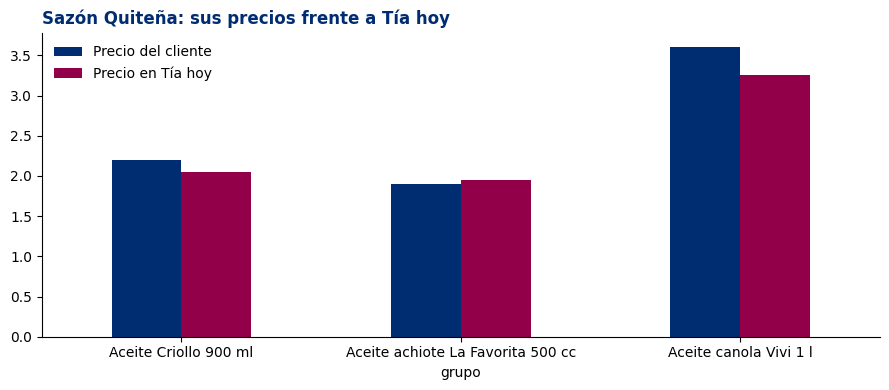

En palabras:
• Aceite Criollo 900 ml: el cliente cobra 2.20 y Tía 2.05; diferencia de -6.8 %: Tía está 6.8 % MÁS BARATA (⚠ SUPERA EL UMBRAL · Tía más barata).
• Aceite achiote La Favorita 500 cc: el cliente cobra 1.90 y Tía 1.95; diferencia de +2.6 %: Tía está 2.6 % MÁS CARA (dentro del umbral).
• Aceite canola Vivi 1 l: el cliente cobra 3.60 y Tía 3.25; diferencia de -9.7 %: Tía está 9.7 % MÁS BARATA (⚠ SUPERA EL UMBRAL · Tía más barata).

Cómo leerlo: negativo = Tía está MÁS BARATA que el cliente · positivo = Tía está MÁS CARA.

✅ Paso 4 listo: ya tienes las cifras de tu respuesta.
🧩 Para el Paso 5: el cuaderno va a ordenar estas cifras para mostrarte lo más importante.


In [11]:
#@title PASO 4 · Medir cuánto cambió { display-mode: "form" }
#@markdown Pulsa el botón redondo (no escribes nada)
paso4()

## PASO 5 · Encontrar lo más importante

**🔗 Lo que ya tienes:** en el Paso 4 mediste cuánto cambió cada uno y cuáles pasan el umbral.

**🎯 En este paso:** ordenas esos cambios de mayor a menor para saber qué es lo primero que le dirás a tu cliente.

**👆 Qué haces:** pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo.

**👀 Qué debes ver:** la frase *«Lo más importante: lo que más cambió fue…»*, la lista ordenada y cuántos pasan el umbral. Al final: `✅ Paso 5 listo`.

**🧩 Lo que te llevas al paso siguiente:** lo más importante, con su cifra.

In [12]:
#@title PASO 5 · Lo más importante { display-mode: "form" }
#@markdown Pulsa el botón redondo (no escribes nada)
paso5()

LO MÁS IMPORTANTE: lo que más cambió fue Aceite canola Vivi 1 l, con -9.7 % (⚠ SUPERA EL UMBRAL · Tía más barata).

De mayor a menor cambio:
  1. Aceite canola Vivi 1 l: -9.7 %  (⚠ SUPERA EL UMBRAL · Tía más barata)
  2. Aceite Criollo 900 ml: -6.8 %  (⚠ SUPERA EL UMBRAL · Tía más barata)
  3. Aceite achiote La Favorita 500 cc: +2.6 %  (dentro del umbral)

2 de 3 superan el umbral de tu cliente (5 %).

✅ Paso 5 listo: ya sabes qué es lo primero que le dirás a tu cliente.
🧩 Para el Paso 6: con estas cifras vas a escribir tu respuesta al cliente.


## PASO 6 · Responderle a tu cliente

**🔗 Lo que ya tienes:** la pregunta de tu cliente (Paso 1), la etiqueta de tus datos (Paso 3), las cifras (Paso 4) y lo más importante (Paso 5).

**🎯 En este paso:** escribes tu respuesta, **con cifras**, como si se la mandaras al cliente.

**👆 Qué haces:** Escribe en cada recuadro de la celda de abajo (una o dos frases en cada uno) y luego pulsa <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">:
- **EL_PROBLEMA**: el problema de tu cliente, con tus palabras.
- **MI_RESPUESTA**: la respuesta a su pregunta, **con cifras de la tabla del Paso 4**.
- **MI_RECOMENDACION**: una decisión concreta que le recomiendas.
- **LO_QUE_NO_PUEDO_AFIRMAR**: algo que estos datos todavía no permiten asegurar.
- **USO_DE_IA**: si usaste IA, cuál y para qué. Si no, deja *No usé IA*.

*Ejemplo de la Práctica 1:* «Entre 2019 y 2025 los precios subieron 7,9 % en Ecuador y 46,4 % en Colombia; solo Colombia pasa el umbral de 10 %.»

**👀 Qué debes ver:** tu respuesta armada como una ficha para el cliente. Si falta algo, el cuaderno te lo dice. Al final: `✅ Paso 6 listo`.

**🧩 Lo que te llevas al paso siguiente:** tu respuesta terminada: ya solo falta entregarla.

In [13]:
#@title PASO 6 · Tu respuesta al cliente { display-mode: "form" }
#@markdown Escribe en cada recuadro y pulsa el botón redondo
EL_PROBLEMA = "Sazón Quiteña busca confrontar los costos de sus aceites con los precios vigentes de Tía a fin de determinar qué productos ofrecen un descuento de al menos 5 % y evaluar si es beneficioso cambiar de proveedor." #@param {type:"string"}
MI_RESPUESTA = "En Tía, el Aceite Criollo 900 ml cuesta $2,05 frente a $2,20 del cliente, lo que representa una diferencia de −6,8 %. El Aceite achiote La Favorita 500 cc presenta una diferencia de +2,6 %, mientras que el Aceite canola Vivi 1 l presenta una diferencia de −9,7 %. Los productos que cumplen el umbral del 5 % son el Aceite Criollo 900 ml y el Aceite canola Vivi 1 l." #@param {type:"string"}
MI_RECOMENDACION = "Recomiendo que Sazón Quiteña considere comprar en Tía el Aceite Criollo 900 ml y el Aceite canola Vivi 1 l, ya que ambos superan el umbral del 5 %, con diferencias de −6,8 % y −9,7 %, respectivamente. Para el Aceite achiote La Favorita 500 cc, cuya diferencia es de +2,6 %, no recomendaría cambiar la compra basándose únicamente en este criterio." #@param {type:"string"}
LO_QUE_NO_PUEDO_AFIRMAR = "Con estos datos no puedo afirmar que Tía sea siempre el proveedor más conveniente, porque solo estamos comparando los precios observados actualmente y no estamos considerando otros factores como costos de transporte, promociones, disponibilidad de los productos o condiciones de compra." #@param {type:"string"}
USO_DE_IA = "Utilicé inteligencia artificial solo para entender las indicaciones y el sentido de ciertos mensajes del cuaderno. Los resultados, los cálculos y la respuesta final fueron generados basándose en la información del ejercicio." #@param {type:"string"}
paso6(EL_PROBLEMA, MI_RESPUESTA, MI_RECOMENDACION, LO_QUE_NO_PUEDO_AFIRMAR, USO_DE_IA)

──────────────────────────────────────────────────────────────────────
RESPUESTA PARA: Sazón Quiteña, restaurante de almuerzos del centro de Quito
PREPARADA POR:  David Ibarra
──────────────────────────────────────────────────────────────────────
El problema (con mis palabras): Sazón Quiteña busca confrontar los costos de sus aceites con los precios vigentes de Tía a fin de determinar qué productos ofrecen un descuento de al menos 5 % y evaluar si es beneficioso cambiar de proveedor.

Su pregunta: ¿Qué aceites le conviene comprar en Tía y cuánto ahorraría por unidad?

Mi respuesta: En Tía, el Aceite Criollo 900 ml cuesta $2,05 frente a $2,20 del cliente, lo que representa una diferencia de −6,8 %. El Aceite achiote La Favorita 500 cc presenta una diferencia de +2,6 %, mientras que el Aceite canola Vivi 1 l presenta una diferencia de −9,7 %. Los productos que cumplen el umbral del 5 % son el Aceite Criollo 900 ml y el Aceite canola Vivi 1 l.

Mi recomendación: Recomiendo que Sazón Quite

## PASO 7 · Guardar y entregar

**🔗 Lo que ya tienes:** tu respuesta terminada (Paso 6). Tu cuaderno se guarda solo en tu Google Drive.

**🎯 En este paso:** entregas **dos cosas**: el **PDF** en Canvas y el **cuaderno** en GitHub.

### A · El PDF, en Canvas (esto es lo que se califica)
1. Menú **Archivo**, opción **Imprimir**.
2. En la ventana que se abre, en **Destino**, elige **Guardar como PDF**. Pulsa **Guardar**. El PDF queda en tu carpeta **Descargas**.
3. En Canvas, abre la tarea **P1-EX · Examen del Parcial 1** y pulsa **Entregar tarea**.
4. Pulsa **Cargar archivo**, elige el PDF que acabas de guardar y pulsa **Entregar tarea**.
5. **Qué debes ver:** Canvas dice **Entregado**.

### B · El cuaderno, en la casa de tu equipo en GitHub
1. Menú **Archivo**, opción **Descargar**, luego **Descargar .ipynb**. El archivo `EXAMEN_P1_TuApellido.ipynb` queda en **Descargas**.
2. Abre la carpeta **examen** de la casa de tu equipo. Busca tu apellido y haz clic en el enlace de tu equipo (tu equipo también aparece en la ficha del Paso 1):
   - **Equipo G01** (Henry Cupacán, Nayeli Lima, Mateo Murgueitio, Sara Sánchez, Zara Tigua): [observatorio-g01 / examen](https://github.com/uide-programacion-inteligencia-mercados/observatorio-g01/tree/main/examen)
   - **Equipo G02** (Diana Andrade, Anthony Landeta, Paula Paredes, Saúl Robalino, David Uriguen): [observatorio-g02 / examen](https://github.com/uide-programacion-inteligencia-mercados/observatorio-g02/tree/main/examen)
   - **Equipo G03** (David Ibarra, Adrián Punina, Emily Ruiz, Micaela Samaniego, Jaime Tapia): [observatorio-g03 / examen](https://github.com/uide-programacion-inteligencia-mercados/observatorio-g03/tree/main/examen)
3. Arriba a la derecha, pulsa el botón **Add file** y luego **Upload files**.
4. Arrastra el archivo `EXAMEN_P1_TuApellido.ipynb` desde tu carpeta Descargas hasta la página.
5. Abajo, pulsa el botón verde **Commit changes**.
6. **Qué debes ver:** tu archivo en la lista de la carpeta **examen**.

*Si GitHub no te deja subir (por ejemplo, porque no aceptaste la invitación a la organización), no pasa nada: tu entrega en Canvas es la que vale.*

**✅ Terminaste.** Revisa que Canvas diga **Entregado** antes de cerrar todo.